# 14. AI-Assisted Causal Code Generation

AI can write code quickly. That is useful. It is also dangerous.

In causal inference, a small coding mistake can change the estimand: adding a post-treatment variable as a control, filtering on an outcome-dependent sample, using future information, fitting a model without overlap diagnostics, or silently changing the treatment definition. The code may run and the table may look professional while the analysis is wrong.

This notebook teaches a safer workflow for AI-assisted causal code generation. The central idea is simple: do not ask an LLM to “write the analysis.” Give it a causal code contract, require tests and diagnostics, review the generated code before execution, and audit the model's plan against deterministic guardrails.

## Mathematical Core

Generated code should be checked against the estimand. If the target is

$$
\tau = \mathbb{E}[Y(1) - Y(0)],
$$

then the code should implement an estimator $\hat\tau$ whose assumptions match the design. A simple regression adjustment estimator has the form

$$
\hat\tau = \frac{1}{n}\sum_{i=1}^{n}\left[\hat\mu(1, X_i) - \hat\mu(0, X_i)\right].
$$

Code review should verify the target, covariate timing, treatment coding, outcome definition, and uncertainty calculation. The model-generated code is a draft implementation, while the mathematical estimand is the contract it must satisfy.


## Learning Goals

By the end of this notebook you should be able to:

1. Explain why causal code generation needs stronger guardrails than ordinary data wrangling code.
2. Write a causal code contract that states the estimand, treatment, outcome, eligible controls, forbidden variables, and diagnostics.
3. Build a deterministic reference implementation for a simple causal analysis.
4. Add lightweight tests that catch common generated-code failures.
5. Use static scanning to flag post-treatment controls, leakage variables, outcome-as-feature errors, and missing diagnostics.
6. Ask local LLMs for structured code-generation plans without automatically executing generated code.
7. Audit AI-generated plans for causal validity, reproducibility, and brittleness.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Code-generation notebooks are especially brittle. A model can produce syntactically correct Python that uses the wrong treatment, controls for a mediator, leaks the future, omits robust standard errors, or silently changes the sample. We will treat those failures as observable workflow risks, not as embarrassing details to hide.

## 1. Setup

The deterministic part of this notebook uses a synthetic customer-retention dataset, a reference regression-adjustment implementation, and static code scanning. The optional live-model sections use the shared local LLM runtime from the previous notebooks.

In [1]:
import ast
import importlib.util
import json
import re
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)

from notebooks._shared.display import smart_display


In [2]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_FAST_MODEL
MAX_NEW_TOKENS = 2000
TEMPERATURE = 0.0
SEED = 214
MODEL_COMPARISON_CASE_LIMIT = 2

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 160)

In [3]:
# Section focus: 1. Setup.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

def has_package(module_name):
    """Carry out the has package step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'data handling and test reports'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'reference causal estimator'},
        {'package': 'ast', 'available': True, 'used_for': 'static syntax scanning of generated code'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI code-generation schema'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM planning'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
smart_display(package_status)

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,data handling and test reports
1,statsmodels,True,reference causal estimator
2,ast,True,static syntax scanning of generated code
3,pydantic,True,structured AI code-generation schema
4,transformers,True,optional local LLM planning
5,torch,True,GPU inference if live LLMs are enabled


## 2. Why Causal Code Generation Is Different

Generic code-generation prompts often optimize for runnable code. Causal analysis needs more:

- The code must preserve the estimand.
- Controls must be pre-treatment and admissible for the target effect.
- Sample restrictions must not condition on post-treatment variables or outcomes.
- Diagnostics must be part of the output, not an afterthought.
- Reproducibility must be explicit: seeds, versions, formulas, and exact feature sets.
- Generated code must be reviewed before execution.

The LLM is allowed to help. It is not allowed to silently redefine the analysis.

| risk | how it appears in generated code | causal consequence |
|---|---|---|
| Post-treatment controls | Adds variables like opened_email or used_discount to the regression because they predict the outcome. | Blocks part of the treatment effect or changes the estimand. |
| Future leakage | Uses future_60d_value or a post-outcome model score as a feature. | Uses information not available at treatment time and contaminates interpretation. |
| Outcome-dependent filtering | Drops rows based on renewal, revenue, survey response, or post-treatment engagement. | Changes the target population and may induce selection bias. |
| Vague treatment definition | Uses treatment uptake, click, or compliance instead of assignment. | Switches from assignment effect to a different exposure without saying so. |
| No diagnostics | Returns one coefficient without balance, overlap, missingness, or robustness checks. | Makes the estimate look cleaner than the design permits. |
| Hallucinated API | Calls nonexistent causal package functions or wrong argument names. | Wastes time and can hide conceptual confusion behind API debugging. |


The recurring theme is that code can be technically valid but causally invalid. The right defense is not “never use AI.” The right defense is to narrow the task, encode guardrails, test outputs, and make the model's responsibilities explicit.

## 3. Running Example: Retention Email Analysis

We will work with a synthetic retention campaign. The business question is:

> What is the total effect of being assigned a retention email on 30-day renewal?

The target estimand is the ATE of `retention_email_assigned` on `renewed_30d`. The valid adjustment candidates are pre-treatment variables. Post-treatment behaviors such as opening the email or using a discount are mediators and should not be controls for the total effect.

In [5]:
# Section focus: 3. Running Example: Retention Email Analysis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def simulate_retention_email_data(n=4500, seed=SEED):
    """Create a simulated retention email data set for the 14. AI-Assisted Causal Code Generation case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    segment = rng.choice(['self_serve', 'team', 'enterprise'], size=n, p=[0.52, 0.33, 0.15])
    region = rng.choice(['Americas', 'EMEA', 'APAC'], size=n, p=[0.46, 0.34, 0.20])
    tenure_months = rng.gamma(shape=2.2, scale=9.0, size=n).clip(1, 84)
    prior_usage = rng.normal(0, 1, size=n)
    prior_tickets = rng.poisson(np.exp(-0.25 - 0.20 * prior_usage + 0.20 * (segment == 'enterprise')), size=n)
    account_value = np.exp(3.05 + 0.35 * (segment == 'enterprise') + 0.15 * prior_usage + rng.normal(0, 0.40, size=n))
    baseline_health = 0.58 * prior_usage + 0.018 * tenure_months - 0.22 * prior_tickets + 0.18 * (region == 'Americas') + rng.normal(0, 0.60, size=n)
    risk_score = -0.82 * baseline_health + 0.25 * prior_tickets + 0.16 * (segment == 'self_serve') + rng.normal(0, 0.45, size=n)
    manager_priority = rng.binomial(1, sigmoid(-0.8 + 0.65 * risk_score + 0.22 * np.log1p(account_value)))

    assignment_logit = -0.25 + 1.05 * risk_score + 0.32 * manager_priority + 0.14 * np.log1p(account_value) + rng.normal(0, 0.65, size=n)
    propensity_true = sigmoid(assignment_logit)
    retention_email_assigned = rng.binomial(1, propensity_true)

    p0 = sigmoid(-0.15 + 0.95 * baseline_health + 0.11 * np.log1p(account_value) - 0.22 * risk_score + 0.10 * (segment == 'enterprise'))
    lift = np.clip(0.035 + 0.040 * sigmoid(risk_score) - 0.010 * np.maximum(baseline_health, 0), -0.01, 0.13)
    p1 = np.clip(p0 + lift, 0.01, 0.99)
    renewal_probability = np.where(retention_email_assigned == 1, p1, p0)
    renewed_30d = rng.binomial(1, renewal_probability)

    opened_email = rng.binomial(1, sigmoid(-1.05 + 1.25 * retention_email_assigned + 0.35 * prior_usage - 0.20 * risk_score))
    clicked_offer = rng.binomial(1, sigmoid(-1.55 + 1.2 * opened_email + 0.45 * retention_email_assigned + 0.20 * manager_priority))
    used_discount = rng.binomial(1, sigmoid(-1.8 + 1.35 * clicked_offer + 0.45 * risk_score))
    support_ticket_after_email = rng.poisson(np.exp(-1.15 + 0.45 * retention_email_assigned + 0.28 * risk_score + 0.18 * prior_tickets))
    revenue_30d = 10 + 0.16 * account_value + 17 * renewed_30d + 5.5 * used_discount + rng.normal(0, 9, size=n)
    future_60d_value = revenue_30d + 0.28 * account_value + 10 * renewed_30d + rng.normal(0, 12, size=n)

    df = pd.DataFrame(
        {
            'customer_id': [f'C{idx:05d}' for idx in range(n)],
            'segment': segment,
            'region': region,
            'tenure_months': tenure_months,
            'prior_usage': prior_usage,
            'prior_tickets': prior_tickets,
            'account_value': account_value,
            'baseline_health': baseline_health,
            'risk_score': risk_score,
            'manager_priority': manager_priority,
            'propensity_true': propensity_true,
            'retention_email_assigned': retention_email_assigned,
            'p0_renewal': p0,
            'p1_renewal': p1,
            'true_individual_effect': p1 - p0,
            'opened_email': opened_email,
            'clicked_offer': clicked_offer,
            'used_discount': used_discount,
            'support_ticket_after_email': support_ticket_after_email,
            'renewed_30d': renewed_30d,
            'revenue_30d': revenue_30d,
            'future_60d_value': future_60d_value,
        }
    )
    truth = {
        'true_ate': float(df['true_individual_effect'].mean()),
        'true_att': float(df.loc[df['retention_email_assigned'].eq(1), 'true_individual_effect'].mean()),
        'treatment_rate': float(df['retention_email_assigned'].mean()),
    }
    return df, truth

raw, truth = simulate_retention_email_data()
raw.head()

,customer_id,segment,region,tenure_months,prior_usage,prior_tickets,account_value,baseline_health,risk_score,manager_priority,...,p0_renewal,p1_renewal,true_individual_effect,opened_email,clicked_offer,used_discount,support_ticket_after_email,renewed_30d,revenue_30d,future_60d_value
0,C00000,self_serve,Americas,36.133477,0.689536,0,26.364742,0.855619,-0.993250,0,...,0.776498,0.813752,0.037255,0,0,0,0,1,40.180236,42.158080
1,C00001,self_serve,Americas,42.705263,-0.669616,1,8.448621,0.557385,0.299279,0,...,0.636619,0.689016,0.052397,1,0,0,0,1,46.230773,68.885369
2,C00002,self_serve,Americas,1.237660,-0.194861,2,25.720880,-0.646292,1.114488,0,...,0.343493,0.408612,0.065119,0,0,1,1,0,16.280600,25.437672
3,C00003,enterprise,Americas,25.844416,-1.342066,2,24.231017,-0.806992,0.868181,1,...,0.342414,0.405589,0.063175,0,0,0,1,0,23.263045,36.707047
4,C00004,self_serve,APAC,13.343537,-0.289272,0,39.395610,-0.104104,0.209554,0,...,0.527935,0.585023,0.057088,0,1,0,1,1,37.108438,40.651581


Treat this output as evidence about the AI-assisted workflow. In Running Example: Retention Email Analysis, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. Use the repair to make the next validation step more precise.


In [6]:
smart_display(truth)

{'true_ate': 0.05041508023424423,
 'true_att': 0.05493345869327715,
 'treatment_rate': 0.5855555555555556}

A good table makes the next check obvious. For Running Example: Retention Email Analysis, the important reading is the pattern across rows, the pattern across rows together with the largest values. The pattern should make the next diagnostic easier to choose.


## 4. Data Dictionary and Code Contract

The contract is the document that constrains generated code. It says what the analysis is allowed to do and what it must not do.

The data dictionary is the bridge between the dataset and generated code. It names each column, its timing, its role, and whether it may be used in the adjustment set. Without this contract, an LLM can write code that runs while silently adjusting for mediators, post-treatment behaviors, or leakage variables.

The experiment is to constrain code generation before it happens. The model should produce analysis code that respects the estimand, uses only allowed variables, reports diagnostics, and avoids forbidden shortcuts. The contract makes those requirements testable.


In [7]:
# Section focus: 4. Data Dictionary and Code Contract.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

data_dictionary = pd.DataFrame(
    [
        {'variable': 'customer_id', 'timing': 'unit id', 'role': 'identifier'},
        {'variable': 'segment', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'region', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'tenure_months', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'prior_usage', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'prior_tickets', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'account_value', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'baseline_health', 'timing': 'pre-treatment', 'role': 'candidate confounder'},
        {'variable': 'risk_score', 'timing': 'pre-treatment', 'role': 'candidate confounder and targeting score'},
        {'variable': 'manager_priority', 'timing': 'pre-treatment', 'role': 'candidate confounder and assignment proxy'},
        {'variable': 'propensity_true', 'timing': 'oracle assignment', 'role': 'simulation-only truth'},
        {'variable': 'retention_email_assigned', 'timing': 'treatment', 'role': 'treatment'},
        {'variable': 'p0_renewal', 'timing': 'potential outcome', 'role': 'simulation-only truth'},
        {'variable': 'p1_renewal', 'timing': 'potential outcome', 'role': 'simulation-only truth'},
        {'variable': 'true_individual_effect', 'timing': 'potential outcome contrast', 'role': 'simulation-only truth'},
        {'variable': 'opened_email', 'timing': 'post-treatment', 'role': 'mediator or compliance behavior'},
        {'variable': 'clicked_offer', 'timing': 'post-treatment', 'role': 'mediator'},
        {'variable': 'used_discount', 'timing': 'post-treatment', 'role': 'mediator'},
        {'variable': 'support_ticket_after_email', 'timing': 'post-treatment', 'role': 'post-treatment descendant'},
        {'variable': 'renewed_30d', 'timing': 'outcome window', 'role': 'primary outcome'},
        {'variable': 'revenue_30d', 'timing': 'outcome window', 'role': 'secondary outcome'},
        {'variable': 'future_60d_value', 'timing': 'future', 'role': 'future leakage'},
    ]
)

smart_display(data_dictionary)

,variable,timing,role
0,customer_id,unit id,identifier
1,segment,pre-treatment,candidate confounder
2,region,pre-treatment,candidate confounder
3,tenure_months,pre-treatment,candidate confounder
4,prior_usage,pre-treatment,candidate confounder
5,prior_tickets,pre-treatment,candidate confounder
6,account_value,pre-treatment,candidate confounder
7,baseline_health,pre-treatment,candidate confounder
8,risk_score,pre-treatment,candidate confounder and targeting score
9,manager_priority,pre-treatment,candidate confounder and assignment proxy


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Data Dictionary and Code Contract. A standout row deserves a second look before it becomes a conclusion.


In [8]:
# Section focus: 4. Data Dictionary and Code Contract.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

analysis_contract = {
    'analysis_id': 'retention_email_total_effect_v1',
    'business_question': 'What is the total effect of retention email assignment on 30-day renewal?',
    'estimand': 'ATE of retention_email_assigned on renewed_30d in the eligible customer population',
    'treatment': 'retention_email_assigned',
    'outcome': 'renewed_30d',
    'method_family': 'regression adjustment with robust standard errors, plus balance and sensitivity diagnostics',
    'allowed_controls': [
        'segment',
        'region',
        'tenure_months',
        'prior_usage',
        'prior_tickets',
        'account_value',
        'baseline_health',
        'risk_score',
        'manager_priority',
    ],
    'categorical_controls': ['segment', 'region'],
    'forbidden_variables': [
        'opened_email',
        'clicked_offer',
        'used_discount',
        'support_ticket_after_email',
        'revenue_30d',
        'future_60d_value',
        'p0_renewal',
        'p1_renewal',
        'true_individual_effect',
        'propensity_true',
    ],
    'required_outputs': ['effect_estimate', 'robust_se', 'confidence_interval', 'balance_table', 'sample_size', 'formula'],
    'required_diagnostics': ['pre-treatment balance', 'overlap proxy', 'missingness check', 'forbidden-variable scan'],
    'execution_policy': 'Do not execute AI-generated analysis code until it passes static review and unit tests.',
}

print(json.dumps(analysis_contract, indent=2))

{
  "analysis_id": "retention_email_total_effect_v1",
  "business_question": "What is the total effect of retention email assignment on 30-day renewal?",
  "estimand": "ATE of retention_email_assigned on renewed_30d in the eligible customer population",
  "treatment": "retention_email_assigned",
  "outcome": "renewed_30d",
  "method_family": "regression adjustment with robust standard errors, plus balance and sensitivity diagnostics",
  "allowed_controls": [
    "segment",
    "region",
    "tenure_months",
    "prior_usage",
    "prior_tickets",
    "account_value",
    "baseline_health",
    "risk_score",
    "manager_priority"
  ],
  "categorical_controls": [
    "segment",
    "region"
  ],
  "forbidden_variables": [
    "opened_email",
    "clicked_offer",
    "used_discount",
    "support_ticket_after_email",
    "revenue_30d",
    "future_60d_value",
    "p0_renewal",
    "p1_renewal",
    "true_individual_effect",
    "propensity_true"
  ],
  "required_outputs": [
    "effect_e

The score matters because it changes how the model would be used. The useful reading is which metric would change the action in Data Dictionary and Code Contract. The analyst should ask which error type should drive the rule.


In [9]:
contract_table = pd.DataFrame(
    [
        {'contract item': 'Estimand', 'value': analysis_contract['estimand'], 'why it matters': 'Prevents the generated code from switching to a compliance or mediator estimand.'},
        {'contract item': 'Treatment', 'value': analysis_contract['treatment'], 'why it matters': 'Keeps assignment distinct from opening, clicking, or discount usage.'},
        {'contract item': 'Outcome', 'value': analysis_contract['outcome'], 'why it matters': 'Prevents future or secondary outcomes from becoming controls.'},
        {'contract item': 'Allowed controls', 'value': ', '.join(analysis_contract['allowed_controls']), 'why it matters': 'Limits adjustment to pre-treatment candidates.'},
        {'contract item': 'Forbidden variables', 'value': ', '.join(analysis_contract['forbidden_variables']), 'why it matters': 'Blocks mediators, future leakage, and simulation-only truth columns.'},
        {'contract item': 'Execution policy', 'value': analysis_contract['execution_policy'], 'why it matters': 'Keeps generated code from running before review.'},
    ]
)
smart_display(contract_table)

,contract item,value,why it matters
0,Estimand,ATE of retention_email_assigned on renewed_30d in the eligible customer population,Prevents the generated code from switching to a compliance or mediator estimand.
1,Treatment,retention_email_assigned,"Keeps assignment distinct from opening, clicking, or discount usage."
2,Outcome,renewed_30d,Prevents future or secondary outcomes from becoming controls.
3,Allowed controls,"segment, region, tenure_months, prior_usage, prior_tickets, account_value, baseline_health, risk_score, manager_priority",Limits adjustment to pre-treatment candidates.
4,Forbidden variables,"opened_email, clicked_offer, used_discount, support_ticket_after_email, revenue_30d, future_60d_value, p0_renewal, p1_renewal, true_individual_effect, prope...","Blocks mediators, future leakage, and simulation-only truth columns."
5,Execution policy,Do not execute AI-generated analysis code until it passes static review and unit tests.,Keeps generated code from running before review.


The contract is more important than the prompt. A prompt can be forgotten, misread, or overruled by a model's learned habits. A contract can be tested.

The metric result should be read as an operating tradeoff. In Data Dictionary and Code Contract, the best-looking score is useful only after we ask which error mode, subgroup, or capacity constraint it affects. A score is meaningful when it sharpens an operating decision.


## 5. Reference Implementation

Before asking an LLM for help, we write a small reference implementation. It is intentionally boring. Boring is good: the point is to preserve the estimand and produce required diagnostics.

In [10]:
# Section focus: 5. Reference Implementation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def validate_analysis_contract(contract, df):
    """Carry out the validate analysis contract step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    df : object
        Input data frame containing the rows used in this notebook example.
    
    Returns
    -------
    object
        Intermediate result produced by the validate analysis contract calculation and reused by later cells.
    """
    required_columns = [contract['treatment'], contract['outcome']] + contract['allowed_controls']
    missing = sorted(set(required_columns) - set(df.columns))
    forbidden_overlap = sorted(set(contract['allowed_controls']).intersection(contract['forbidden_variables']))
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
    if forbidden_overlap:
        raise ValueError(f'Allowed controls contain forbidden variables: {forbidden_overlap}')
    return True


def formula_term(variable, categorical_controls):
    """Carry out the formula term step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    variable : object
        Column or variable name used to select information from the input table.
    categorical_controls : object
        The categorical controls setting that controls the formula term calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the formula term calculation and reused by later cells.
    """
    return f'C({variable})' if variable in categorical_controls else variable


def build_adjustment_formula(contract):
    """Build the adjustment formula object used in the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Intermediate result produced by the adjustment formula calculation and reused by later cells.
    """
    control_terms = [formula_term(variable, contract['categorical_controls']) for variable in contract['allowed_controls']]
    return f"{contract['outcome']} ~ {contract['treatment']} + " + ' + '.join(control_terms)


def standardized_mean_difference(df, treatment, variables):
    """Carry out the standardized mean difference step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    variables : object
        Column or variable name used to select information from the input table.
    
    Returns
    -------
    object
        Intermediate result produced by the standardized mean difference calculation and reused by later cells.
    """
    rows = []
    treated = df[df[treatment].eq(1)]
    control = df[df[treatment].eq(0)]
    for variable in variables:
        if not pd.api.types.is_numeric_dtype(df[variable]):
            continue
        t = treated[variable].dropna()
        c = control[variable].dropna()
        pooled_sd = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
        smd = np.nan if pooled_sd == 0 or np.isnan(pooled_sd) else (t.mean() - c.mean()) / pooled_sd
        rows.append({'variable': variable, 'smd': smd, 'abs_smd': abs(smd) if not np.isnan(smd) else np.nan})
    return pd.DataFrame(rows).sort_values('abs_smd', ascending=False)


def missingness_table(df, contract):
    """Carry out the missingness table step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the missingness table workflow for later analysis.
    """
    columns = [contract['treatment'], contract['outcome']] + contract['allowed_controls']
    return (
        df[columns]
        .isna()
        .mean()
        .rename('missing_share')
        .reset_index()
        .rename(columns={'index': 'variable'})
        .sort_values('missing_share', ascending=False)
    )


def run_reference_analysis(df, contract):
    """Run the reference analysis workflow for the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    validate_analysis_contract(contract, df)
    formula = build_adjustment_formula(contract)
    fitted = smf.ols(formula, data=df).fit(cov_type='HC3')
    treatment = contract['treatment']
    estimate = fitted.params[treatment]
    robust_se = fitted.bse[treatment]
    ci = (estimate - 1.96 * robust_se, estimate + 1.96 * robust_se)
    balance = standardized_mean_difference(df, treatment, contract['allowed_controls'])
    missing = missingness_table(df, contract)
    overlap_proxy = df.groupby(treatment)['risk_score'].describe()[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].reset_index()
    return {
        'effect_estimate': float(estimate),
        'robust_se': float(robust_se),
        'confidence_interval': tuple(float(x) for x in ci),
        'sample_size': int(fitted.nobs),
        'formula': formula,
        'balance_table': balance,
        'missingness_table': missing,
        'overlap_proxy': overlap_proxy,
        'model': fitted,
    }

reference_result = run_reference_analysis(raw, analysis_contract)
{k: v for k, v in reference_result.items() if k not in {'model', 'balance_table', 'missingness_table', 'overlap_proxy'}}

{'effect_estimate': 0.04200816168672993,
 'robust_se': 0.014626962837598567,
 'confidence_interval': (0.013339314525036741, 0.07067700884842312),
 'sample_size': 4500,
 'formula': 'renewed_30d ~ retention_email_assigned + C(segment) + C(region) + tenure_months + prior_usage + prior_tickets + account_value + baseline_health + risk_score + manager_priority'}

This result sits between model performance and the operating policy. The useful reading is which metric would change the action in Reference Implementation. The analyst should resolve metric disagreement through the operating constraint.


In [11]:
reference_result['balance_table'].head(8)

,variable,smd,abs_smd
5,risk_score,0.905285,0.905285
4,baseline_health,-0.762763,0.762763
1,prior_usage,-0.491671,0.491671
2,prior_tickets,0.419444,0.419444
6,manager_priority,0.331019,0.331019
0,tenure_months,-0.184085,0.184085
3,account_value,-0.140114,0.140114


Putting the idea in a table makes it easier to challenge. For Reference Implementation, the important reading is the pattern across rows, the pattern across rows together with the largest values. The result should lead into a diagnostic, threshold check, or policy update.


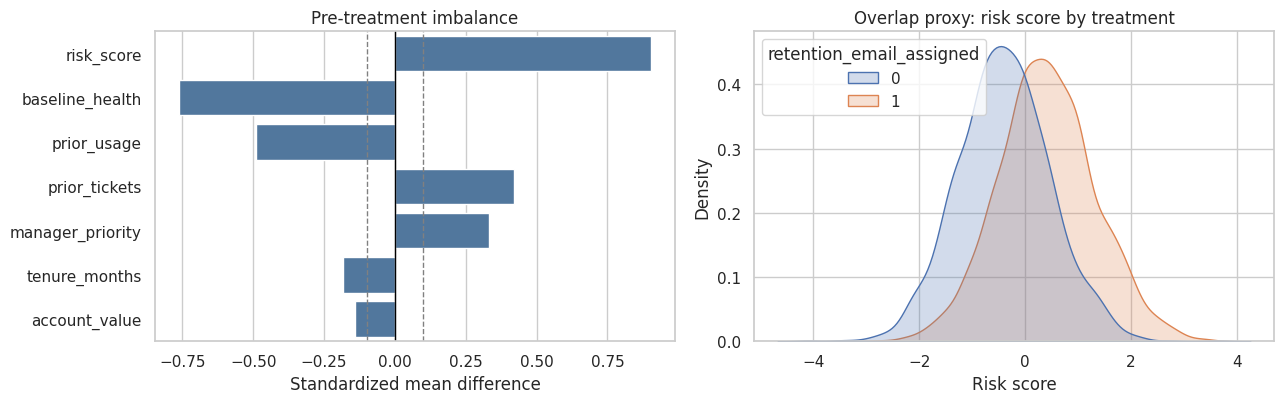

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(data=reference_result['balance_table'].head(8), y='variable', x='smd', color='#4477AA', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].axvline(0.10, color='gray', linestyle='--', linewidth=1)
axes[0].axvline(-0.10, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Pre-treatment imbalance')
axes[0].set_xlabel('Standardized mean difference')
axes[0].set_ylabel('')

sns.kdeplot(data=raw, x='risk_score', hue='retention_email_assigned', common_norm=False, fill=True, alpha=0.25, ax=axes[1])
axes[1].set_title('Overlap proxy: risk score by treatment')
axes[1].set_xlabel('Risk score')
plt.tight_layout()
plt.show()

The reference implementation does not prove identification. It provides a clean baseline that generated code must match or improve upon. It also makes diagnostics first-class outputs rather than optional narrative.

This visual check catches patterns that an average score would flatten. For Reference Implementation, look for where groups separate, where curves bend, or where the tails behave differently. Use those features to decide what needs modeling attention and what needs operational attention.


## 6. Lightweight Tests for Generated Causal Code

Tests are software hygiene and design protection. In causal workflows, tests preserve design decisions.

In [13]:
# Section focus: 6. Lightweight Tests for Generated Causal Code.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def run_contract_tests(df, contract, result):
    """Run the contract tests workflow for the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    result : object
        The result setting that controls the contract tests calculation in this notebook.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    tests = []

    def record(name, passed, detail):
        """Carry out the record step used in the 14. AI-Assisted Causal Code Generation workflow.
        
        Parameters
        ----------
        name : object
            Readable name used to label a model, variable, scenario, or diagnostic object.
        passed : object
            The passed setting that controls the record calculation in this notebook.
        detail : object
            The detail setting that controls the record calculation in this notebook.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        tests.append({'test': name, 'passed': bool(passed), 'detail': detail})

    formula = result['formula']
    forbidden_in_formula = [var for var in contract['forbidden_variables'] if re.search(rf'\b{re.escape(var)}\b', formula)]
    record('formula excludes forbidden variables', len(forbidden_in_formula) == 0, f'forbidden_in_formula={forbidden_in_formula}')

    allowed_missing = sorted(set(contract['allowed_controls']) - set(df.columns))
    record('all allowed controls exist', len(allowed_missing) == 0, f'missing_allowed_controls={allowed_missing}')

    required_outputs = set(contract['required_outputs'])
    available_outputs = set(result.keys())
    missing_outputs = sorted(required_outputs - available_outputs)
    record('required outputs are present', len(missing_outputs) == 0, f'missing_outputs={missing_outputs}')

    record('robust standard error is positive', result['robust_se'] > 0, f"robust_se={result['robust_se']:.4f}")
    record('sample size matches input rows', result['sample_size'] == len(df), f"sample_size={result['sample_size']}, rows={len(df)}")
    record('balance table produced', isinstance(result['balance_table'], pd.DataFrame) and not result['balance_table'].empty, 'balance_table is non-empty')
    record('missingness table produced', isinstance(result['missingness_table'], pd.DataFrame) and not result['missingness_table'].empty, 'missingness_table is non-empty')

    estimate_close_enough_for_teaching = abs(result['effect_estimate'] - truth['true_ate']) < 0.12
    record('estimate is within broad teaching tolerance of synthetic truth', estimate_close_enough_for_teaching, f"estimate={result['effect_estimate']:.4f}, true_ate={truth['true_ate']:.4f}")
    return pd.DataFrame(tests)

test_report = run_contract_tests(raw, analysis_contract, reference_result)
smart_display(test_report)

,test,passed,detail
0,formula excludes forbidden variables,True,forbidden_in_formula=[]
1,all allowed controls exist,True,missing_allowed_controls=[]
2,required outputs are present,True,missing_outputs=[]
3,robust standard error is positive,True,robust_se=0.0146
4,sample size matches input rows,True,"sample_size=4500, rows=4500"
5,balance table produced,True,balance_table is non-empty
6,missingness table produced,True,missingness_table is non-empty
7,estimate is within broad teaching tolerance of synthetic truth,True,"estimate=0.0420, true_ate=0.0504"


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Lightweight Tests for Generated Causal Code. The row that changes the next review step deserves attention.


In [14]:
test_report['passed'].all()

np.True_

The last test uses a broad teaching tolerance because this simple regression is not promised to be exact. In production, tests would not usually assert that an estimate is near truth because truth is unknown. In synthetic labs, that extra check is useful.

For Lightweight Tests for Generated Causal Code, focus on the part of the result that would change the workflow. A defensible analysis should connect the artifact to a concrete decision step.


## 7. Static Review of Generated Code

Generated code should not be executed automatically. First, parse it, scan it, and review it.

The example below is intentionally bad. It runs plausible-looking causal code but includes mediators and future leakage as controls.

In [15]:
bad_generated_code = '''
import statsmodels.formula.api as smf

controls = [
    "segment", "region", "tenure_months", "prior_usage", "prior_tickets",
    "account_value", "baseline_health", "risk_score", "manager_priority",
    "opened_email", "clicked_offer", "used_discount", "future_60d_value"
]
formula = "renewed_30d ~ retention_email_assigned + " + " + ".join(controls)
model = smf.ols(formula, data=df[df["opened_email"] == 1]).fit()
print(model.summary())
'''

print(bad_generated_code)


import statsmodels.formula.api as smf

controls = [
    "segment", "region", "tenure_months", "prior_usage", "prior_tickets",
    "account_value", "baseline_health", "risk_score", "manager_priority",
    "opened_email", "clicked_offer", "used_discount", "future_60d_value"
]
formula = "renewed_30d ~ retention_email_assigned + " + " + ".join(controls)
model = smf.ols(formula, data=df[df["opened_email"] == 1]).fit()
print(model.summary())



This table gives the quantitative checkpoint for Static Review of Generated Code. A row matters when it would change how the workflow is run. Use wide gaps and failure clusters to choose the next validation step.


In [16]:
# Section focus: 7. Static Review of Generated Code.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def scan_generated_code(code_text, contract):
    """Carry out the scan generated code step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    code_text : object
        Text produced or inspected by the language-model workflow.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    risks = []
    try:
        ast.parse(code_text)
        syntax_valid = True
    except SyntaxError as error:
        syntax_valid = False
        risks.append({'risk_type': 'syntax_error', 'severity': 'blocker', 'evidence': str(error)})

    for variable in contract['forbidden_variables']:
        if re.search(rf'\b{re.escape(variable)}\b', code_text):
            risks.append({'risk_type': 'forbidden_variable_used', 'severity': 'blocker', 'evidence': variable})

    if '.fit()' in code_text and 'cov_type' not in code_text:
        risks.append({'risk_type': 'missing_robust_standard_errors', 'severity': 'warning', 'evidence': 'model fit does not request robust covariance'})

    if re.search(r'\[[^\]]*(opened_email|clicked_offer|used_discount|renewed_30d|revenue_30d|future_60d_value)[^\]]*\]', code_text):
        risks.append({'risk_type': 'post_treatment_or_outcome_filter', 'severity': 'blocker', 'evidence': 'sample restriction appears to use post-treatment/outcome/future variable'})

    if contract['treatment'] not in code_text:
        risks.append({'risk_type': 'missing_treatment', 'severity': 'blocker', 'evidence': contract['treatment']})

    if contract['outcome'] not in code_text:
        risks.append({'risk_type': 'missing_outcome', 'severity': 'blocker', 'evidence': contract['outcome']})

    if not any(term in code_text.lower() for term in ['balance', 'smd', 'standardized mean difference', 'overlap']):
        risks.append({'risk_type': 'missing_diagnostics', 'severity': 'warning', 'evidence': 'no balance or overlap diagnostic detected'})

    return pd.DataFrame(risks), syntax_valid

bad_scan, bad_syntax_valid = scan_generated_code(bad_generated_code, analysis_contract)
smart_display(bad_scan)

,risk_type,severity,evidence
0,forbidden_variable_used,blocker,opened_email
1,forbidden_variable_used,blocker,clicked_offer
2,forbidden_variable_used,blocker,used_discount
3,forbidden_variable_used,blocker,future_60d_value
4,missing_robust_standard_errors,warning,model fit does not request robust covariance
5,post_treatment_or_outcome_filter,blocker,sample restriction appears to use post-treatment/outcome/future variable
6,missing_diagnostics,warning,no balance or overlap diagnostic detected


This is exactly the kind of code that can fool a rushed analyst. It runs. It uses familiar libraries. It even includes many valid controls. But it also filters on `opened_email`, controls for mediators, uses future leakage, and omits robust standard errors.

A static scan cannot prove code is correct, but it can catch many obvious failures before execution.

## 8. A Safer Code-Generation Prompt

A safer prompt does not ask for an entire notebook in one shot. It asks for a constrained plan, explicit tests, and a small implementation surface.

In [17]:
code_generation_request = {
    'task': 'Generate a Python function that estimates the ATE of retention_email_assigned on renewed_30d using regression adjustment.',
    'contract': analysis_contract,
    'data_dictionary': data_dictionary.to_dict(orient='records'),
    'required_behavior': [
        'Use only allowed_controls in the adjustment formula.',
        'Use HC3 robust standard errors.',
        'Return effect estimate, standard error, confidence interval, formula, sample size, balance table, and missingness table.',
        'Do not filter rows based on post-treatment variables, outcomes, or future variables.',
        'Do not execute code automatically; provide code and tests for review.',
    ],
    'forbidden_behavior': [
        'Do not use opened_email, clicked_offer, used_discount, support_ticket_after_email, future_60d_value, p0_renewal, p1_renewal, true_individual_effect, or propensity_true.',
        'Do not redefine treatment as opening, clicking, or discount usage.',
        'Do not report a single coefficient without diagnostics.',
    ],
}

print(json.dumps(code_generation_request, indent=2)[:4500])

{
  "task": "Generate a Python function that estimates the ATE of retention_email_assigned on renewed_30d using regression adjustment.",
  "contract": {
    "analysis_id": "retention_email_total_effect_v1",
    "business_question": "What is the total effect of retention email assignment on 30-day renewal?",
    "estimand": "ATE of retention_email_assigned on renewed_30d in the eligible customer population",
    "treatment": "retention_email_assigned",
    "outcome": "renewed_30d",
    "method_family": "regression adjustment with robust standard errors, plus balance and sensitivity diagnostics",
    "allowed_controls": [
      "segment",
      "region",
      "tenure_months",
      "prior_usage",
      "prior_tickets",
      "account_value",
      "baseline_health",
      "risk_score",
      "manager_priority"
    ],
    "categorical_controls": [
      "segment",
      "region"
    ],
    "forbidden_variables": [
      "opened_email",
      "clicked_offer",
      "used_discount",
      

The prompt asks for a plan and reviewable code. It does not ask the model to run code. This separation matters. Code execution should happen only after static review and tests.

A Safer Code-Generation Prompt should lead to a practical question: what would this result make the analyst check, revise, or defend next?


## 9. Shared Local LLM Runtime

We reuse the shared local LLM utilities from `notebooks/_shared` so model loading and cleanup behavior matches earlier notebooks.

In [18]:
# Section focus: 9. Shared Local LLM Runtime.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def find_project_root(start=None):
    """Carry out the find project root step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 10. Structured AI Code-Generation Plan

Instead of asking for raw code first, we ask for a structured plan. The plan must name guardrails, tests, diagnostics, and execution policy.

In [19]:
# Section focus: 10. Structured AI Code-Generation Plan.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class CausalCodeGenerationPlan(BaseModel):
    task_summary: str = Field(description='Brief summary of the requested causal code task.')
    estimand: str = Field(description='The causal estimand that the code must preserve.')
    implementation_plan: list[str] = Field(description='Step-by-step implementation plan.')
    allowed_inputs: list[str] = Field(description='Variables that may be used by the analysis code.')
    forbidden_inputs: list[str] = Field(description='Variables that must not be used as controls or filters.')
    required_tests: list[str] = Field(description='Tests that should be written before executing generated code.')
    required_diagnostics: list[str] = Field(description='Diagnostics the code must return.')
    static_review_checks: list[str] = Field(description='Static scans or code review checks before execution.')
    execution_policy: str = Field(description='Policy for whether generated code may be executed automatically.')
    risky_failure_modes: list[str] = Field(description='Common ways this generated code could be causally wrong.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the plan given the contract.')

PLAN_SCALAR_FIELDS = ['task_summary', 'estimand', 'execution_policy', 'confidence']
PLAN_LIST_FIELDS = [
    'implementation_plan',
    'allowed_inputs',
    'forbidden_inputs',
    'required_tests',
    'required_diagnostics',
    'static_review_checks',
    'risky_failure_modes',
]
PLAN_ALIASES = {
    'plan': 'implementation_plan',
    'allowed_variables': 'allowed_inputs',
    'forbidden_variables': 'forbidden_inputs',
    'tests': 'required_tests',
    'diagnostics': 'required_diagnostics',
    'review_checks': 'static_review_checks',
    'failure_modes': 'risky_failure_modes',
}


def parse_code_generation_plan(raw_output):
    """Carry out the parse code generation plan step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    result = parse_pydantic_output(
        raw_output,
        CausalCodeGenerationPlan,
        scalar_fields=PLAN_SCALAR_FIELDS,
        list_fields=PLAN_LIST_FIELDS,
        field_aliases=PLAN_ALIASES,
        defaults={'confidence': 'medium'},
    )
    return result.parsed, result.json_text, result.notes

In [20]:
# Section focus: 10. Structured AI Code-Generation Plan.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_CODE_MESSAGE = (
    'You are a careful causal inference code-generation reviewer.\n'
    'Rules:\n'
    '- Use only the provided code-generation request.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Preserve the stated estimand.\n'
    '- Do not recommend using forbidden variables as controls, filters, features, or diagnostics that affect estimation.\n'
    '- Do not claim generated code should be executed before static review and tests.\n'
    '- Include tests for forbidden variables, treatment/outcome correctness, required outputs, robust standard errors, and diagnostics.\n'
    '- Mention brittleness and generated-code failure modes explicitly.'
)


def build_code_plan_prompt(request):
    """Build the code plan prompt object used in the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    request : object
        The request setting that controls the code plan prompt calculation in this notebook.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the code plan prompt workflow.
    """
    schema_hint = {
        'task_summary': 'string',
        'estimand': 'string',
        'implementation_plan': ['string'],
        'allowed_inputs': ['string'],
        'forbidden_inputs': ['string'],
        'required_tests': ['string'],
        'required_diagnostics': ['string'],
        'static_review_checks': ['string'],
        'execution_policy': 'string',
        'risky_failure_modes': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a CausalCodeGenerationPlan JSON object using this schema:
        {json.dumps(schema_hint, indent=2)}

        Code-generation request:
        {json.dumps(request, indent=2)}
        '''
    ).strip()

code_plan_prompt = build_code_plan_prompt(code_generation_request)
print(code_plan_prompt[:3000])

Produce a CausalCodeGenerationPlan JSON object using this schema:
        {
  "task_summary": "string",
  "estimand": "string",
  "implementation_plan": [
    "string"
  ],
  "allowed_inputs": [
    "string"
  ],
  "forbidden_inputs": [
    "string"
  ],
  "required_tests": [
    "string"
  ],
  "required_diagnostics": [
    "string"
  ],
  "static_review_checks": [
    "string"
  ],
  "execution_policy": "string",
  "risky_failure_modes": [
    "string"
  ],
  "confidence": "low | medium | high"
}

        Code-generation request:
        {
  "task": "Generate a Python function that estimates the ATE of retention_email_assigned on renewed_30d using regression adjustment.",
  "contract": {
    "analysis_id": "retention_email_total_effect_v1",
    "business_question": "What is the total effect of retention email assignment on 30-day renewal?",
    "estimand": "ATE of retention_email_assigned on renewed_30d in the eligible customer population",
    "treatment": "retention_email_assigned"

For Structured AI Code-Generation Plan, treat the response as a small experiment in model behavior. Keep the checkable parts and record the drift, omissions, or inventions.


## 11. Run One Local Model

We start with the fast local model. A good plan should refuse automatic execution, list forbidden variables, require tests, and preserve the total-effect estimand.

In [21]:
if RUN_LIVE_LOCAL_LLM:
    raw_plan_output = local_chat(
        code_plan_prompt,
        system_message=SYSTEM_CODE_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    smart_display(Markdown('### Raw model output'))
    smart_display(Markdown(f'```json\n{clean_generated_text(raw_plan_output)}\n```'))
else:
    raw_plan_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "task_summary": "Estimate the ATE of retention_email_assigned on renewed_30d using regression adjustment with robust standard errors and balance diagnostics.",
 "estimand": "ATE of retention_email_assigned on renewed_30d in the eligible customer population",
 "implementation_plan": [
 "Load the dataset containing the variables.",
 "Check for missing values and handle them appropriately.",
 "Create dummy variables for categorical controls: segment and region.",
 "Fit a regression model adjusting for the specified controls.",
 "Calculate the effect estimate, robust standard errors, and confidence intervals.",
 "Generate a balance table to assess covariate balance.",
 "Report the sample size, formula, and diagnostics.",
 "Ensure no forbidden variables are used in the analysis."
 ],
 "allowed_inputs": [
 "customer_id",
 "segment",
 "region",
 "tenure_months",
 "prior_usage",
 "prior_tickets",
 "account_value",
 "baseline_health",
 "risk_score",
 "manager_priority",
 "retention_email_assigned",
 "renewed_30d"
 ],
 "forbidden_inputs": [
 "opened_email",
 "clicked_offer",
 "used_discount",
 "support_ticket_after_email",
 "revenue_30d",
 "future_60d_value",
 "p0_renewal",
 "p1_renewal",
 "true_individual_effect",
 "propensity_true"
 ],
 "required_tests": [
 "Check for missing values in the dataset and ensure they are handled correctly.",
 "Verify that the treatment variable (retention_email_assigned) is binary.",
 "Confirm that the outcome variable (renewed_30d) is binary.",
 "Ensure that all allowed controls are included in the model.",
 "Test that the model uses HC3 robust standard errors.",
 "Validate that the effect estimate, standard error, confidence interval, formula, sample size, balance table, and missingness table are returned."
 ],
 "required_diagnostics": [
 "Pre-treatment balance test between treatment groups.",
 "Overlap proxy to check for common support.",
 "Missingness check to ensure no missing data in key variables.",
 "Forbidden-variable scan to confirm no forbidden variables are used."
 ],
 "static_review_checks": [
 "Ensure the code does not filter rows based on post-treatment variables, outcomes, or future variables.",
 "Verify that the treatment variable is not redefined as opening, clicking, or discount usage.",
 "Check that the model includes only the allowed controls.",
 "Confirm that the model uses HC3 robust standard errors.",
 "Ensure that the output includes the required diagnostics and statistics."
 ],
 "execution_policy": "Do not execute AI-generated analysis code until it passes static review and unit tests.",
 "risky_failure_modes": [
 "Incorrect handling of missing data could lead to biased estimates.",
 "Using forbidden variables could result in invalid causal inference.",
 "Failing to include necessary controls could lead to imprecise estimates.",
 "Not using HC3 robust standard errors could result in incorrect standard errors.",
 "Failing to perform balance checks could indicate poor covariate balance."
 ],
 "confidence": "medium"
}
```

In Run One Local Model, the response earns credit by being specific, cautious, and easy to audit.


In [22]:
if raw_plan_output:
    try:
        code_plan, code_plan_json, plan_parser_notes = parse_code_generation_plan(raw_plan_output)
        single_model_parse_error = ''
        smart_display(Markdown('### Parsed code-generation plan'))
        smart_display(Markdown(f'```json\n{code_plan.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', plan_parser_notes)
    except Exception as error:
        code_plan = None
        code_plan_json = ''
        plan_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    code_plan = None
    code_plan_json = ''
    plan_parser_notes = []
    single_model_parse_error = ''

### Parsed code-generation plan

```json
{
  "task_summary": "Estimate the ATE of retention_email_assigned on renewed_30d using regression adjustment with robust standard errors and balance diagnostics.",
  "estimand": "ATE of retention_email_assigned on renewed_30d in the eligible customer population",
  "implementation_plan": [
    "Load the dataset containing the variables.",
    "Check for missing values and handle them appropriately.",
    "Create dummy variables for categorical controls: segment and region.",
    "Fit a regression model adjusting for the specified controls.",
    "Calculate the effect estimate, robust standard errors, and confidence intervals.",
    "Generate a balance table to assess covariate balance.",
    "Report the sample size, formula, and diagnostics.",
    "Ensure no forbidden variables are used in the analysis."
  ],
  "allowed_inputs": [
    "customer_id",
    "segment",
    "region",
    "tenure_months",
    "prior_usage",
    "prior_tickets",
    "account_value",
    "baseline_health",
    "risk_score",
    "manager_priority",
    "retention_email_assigned",
    "renewed_30d"
  ],
  "forbidden_inputs": [
    "opened_email",
    "clicked_offer",
    "used_discount",
    "support_ticket_after_email",
    "revenue_30d",
    "future_60d_value",
    "p0_renewal",
    "p1_renewal",
    "true_individual_effect",
    "propensity_true"
  ],
  "required_tests": [
    "Check for missing values in the dataset and ensure they are handled correctly.",
    "Verify that the treatment variable (retention_email_assigned) is binary.",
    "Confirm that the outcome variable (renewed_30d) is binary.",
    "Ensure that all allowed controls are included in the model.",
    "Test that the model uses HC3 robust standard errors.",
    "Validate that the effect estimate, standard error, confidence interval, formula, sample size, balance table, and missingness table are returned."
  ],
  "required_diagnostics": [
    "Pre-treatment balance test between treatment groups.",
    "Overlap proxy to check for common support.",
    "Missingness check to ensure no missing data in key variables.",
    "Forbidden-variable scan to confirm no forbidden variables are used."
  ],
  "static_review_checks": [
    "Ensure the code does not filter rows based on post-treatment variables, outcomes, or future variables.",
    "Verify that the treatment variable is not redefined as opening, clicking, or discount usage.",
    "Check that the model includes only the allowed controls.",
    "Confirm that the model uses HC3 robust standard errors.",
    "Ensure that the output includes the required diagnostics and statistics."
  ],
  "execution_policy": "Do not execute AI-generated analysis code until it passes static review and unit tests.",
  "risky_failure_modes": [
    "Incorrect handling of missing data could lead to biased estimates.",
    "Using forbidden variables could result in invalid causal inference.",
    "Failing to include necessary controls could lead to imprecise estimates.",
    "Not using HC3 robust standard errors could result in incorrect standard errors.",
    "Failing to perform balance checks could indicate poor covariate balance."
  ],
  "confidence": "medium"
}
```

Parser notes: []


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Run One Local Model. The practical question is whether the difference survives a robustness check.


## 12. Audit the AI Code Plan

A good code-generation plan is not judged by eloquence. It is judged by whether it protects the causal contract.

In [23]:
# Section focus: 12. Audit the AI Code Plan.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def plan_text(plan):
    """Carry out the plan text step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    plan : object
        The plan setting that controls the plan text calculation in this notebook.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the plan text workflow.
    """
    if plan is None:
        return ''
    return clean_generated_text(json.dumps(plan.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    """Carry out the contains any step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    terms : object
        Search terms, concept terms, or model-output terms being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    return any(term.lower() in text for term in terms)


def forbidden_in_allowed_inputs(plan, contract):
    """Carry out the forbidden in allowed inputs step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    plan : object
        The plan setting that controls the forbidden in allowed inputs calculation in this notebook.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Array-like values produced by the calculation.
    """
    if plan is None:
        return []
    allowed_text = ' '.join(plan.allowed_inputs).lower()
    return [variable for variable in contract['forbidden_variables'] if variable.lower() in allowed_text]


def score_code_plan(plan, contract):
    """Score code plan for the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    plan : object
        The plan setting that controls the code plan calculation in this notebook.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    text = plan_text(plan)
    forbidden_allowed = forbidden_in_allowed_inputs(plan, contract)
    checks = {
        'states estimand': contract['treatment'] in text and contract['outcome'] in text and 'ate' in text,
        'lists allowed pre-treatment controls': sum(variable in text for variable in contract['allowed_controls']) >= 6,
        'lists forbidden variables': sum(variable in text for variable in contract['forbidden_variables']) >= 5,
        'forbidden variables absent from allowed inputs': len(forbidden_allowed) == 0,
        'requires forbidden-variable test': contains_any(text, ['forbidden', 'post-treatment', 'leakage']),
        'requires robust standard errors': contains_any(text, ['hc3', 'robust standard', 'robust se']),
        'requires diagnostics': contains_any(text, ['balance', 'overlap', 'missingness']),
        'requires static review': contains_any(text, ['static', 'scan', 'ast', 'review before execution']),
        'forbids automatic execution': contains_any(text, ['do not execute', 'not execute', 'before execution', 'manual review']),
        'mentions generated-code brittleness': contains_any(text, ['brittle', 'brittleness', 'hallucinated', 'failure mode', 'wrong estimand']),
        'does not claim code is automatically valid': not contains_any(text, ['guarantees correctness', 'safe to execute immediately', 'automatically valid']),
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit), forbidden_allowed

if code_plan is not None:
    single_audit, single_score, single_max_score, forbidden_allowed = score_code_plan(code_plan, analysis_contract)
    print(f'Score: {single_score}/{single_max_score}')
    print('Forbidden variables listed as allowed inputs:', forbidden_allowed)
    smart_display(single_audit)
else:
    print('No code plan to audit because live model execution was skipped or parsing failed.')

Score: 10/11
Forbidden variables listed as allowed inputs: []


,check,passed,credit
0,states estimand,True,1
1,lists allowed pre-treatment controls,True,1
2,lists forbidden variables,True,1
3,forbidden variables absent from allowed inputs,True,1
4,requires forbidden-variable test,True,1
5,requires robust standard errors,True,1
6,requires diagnostics,True,1
7,requires static review,True,1
8,forbids automatic execution,True,1
9,mentions generated-code brittleness,False,0


The audit gives hard credit for causal guardrails. A plan that says “write a regression” but forgets bad controls, robust standard errors, diagnostics, or execution policy is not good enough for causal work.

A compact table helps the analyst see what has been specified and what still needs work. For Audit the AI Code Plan, the important reading is the pattern across rows, the pattern across rows together with the largest values. This pattern should lead to a concrete review or policy adjustment.


## 13. Optional All-Model Comparison

Now we compare local models on multiple code-generation tasks. The goal is not to pick a permanent winner. The goal is to see which models preserve the code contract most reliably.

The exact ranking can change across reruns and environments. That is expected. Generated-code brittleness is part of what we are measuring.

In [24]:
# Section focus: 13. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

ipw_code_generation_request = {
    'task': 'Generate a Python function that estimates the ATE of retention_email_assigned on renewed_30d using inverse probability weighting.',
    'contract': {**analysis_contract, 'method_family': 'propensity score weighting / IPW with balance and weight diagnostics'},
    'data_dictionary': data_dictionary.to_dict(orient='records'),
    'required_behavior': [
        'Estimate propensity using only allowed pre-treatment controls.',
        'Return treatment effect estimate, weight summary, effective sample size proxy, balance before and after weighting, and missingness table.',
        'Clip or diagnose extreme propensities; do not silently accept unstable weights.',
        'Do not execute code automatically; provide code and tests for review.',
    ],
    'forbidden_behavior': code_generation_request['forbidden_behavior'],
}

CODE_PLAN_EVAL_CASES = [
    {'case_id': 'regression_adjustment_code_plan', 'request': code_generation_request, 'contract': analysis_contract},
    {'case_id': 'ipw_code_plan', 'request': ipw_code_generation_request, 'contract': analysis_contract},
]

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_plan_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'status', 'schema_valid', 'repair_used',
    'repair_stage', 'error_type', 'plan_score', 'max_plan_score', 'plan_score_share',
    'forbidden_allowed', 'error', 'raw_output_preview'
]

SCHEMA_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required CausalCodeGenerationPlan JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims or new code behavior.

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_code_plan():
    """Carry out the empty code plan step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Intermediate result produced by the empty code plan calculation and reused by later cells.
    """
    return CausalCodeGenerationPlan(
        task_summary='',
        estimand='',
        implementation_plan=[],
        allowed_inputs=[],
        forbidden_inputs=[],
        required_tests=[],
        required_diagnostics=[],
        static_review_checks=[],
        execution_policy='',
        risky_failure_modes=[],
        confidence='low',
    )


def parse_or_repair_plan(raw_output, model_id):
    """Carry out the parse or repair plan step used in the 14. AI-Assisted Causal Code Generation workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_code_generation_plan(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = SCHEMA_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:7000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_CODE_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_code_generation_plan(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_code_plan_case(label, model_id, role, case):
    """Run the single model code plan case workflow for the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    prompt = build_code_plan_prompt(case['request'])
    raw_output = ''
    max_score = score_code_plan(empty_code_plan(), case['contract'])[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_CODE_MESSAGE,
            model_id=model_id,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_plan(raw_output, model_id)
        audit, score, max_score, forbidden_allowed = score_code_plan(parsed_result['parsed'], case['contract'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'plan_score': score,
            'max_plan_score': max_score,
            'plan_score_share': score / max_score if max_score else 0.0,
            'forbidden_allowed': forbidden_allowed,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'plan_score': 0,
            'max_plan_score': max_score,
            'plan_score_share': 0.0,
            'forbidden_allowed': [],
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    """Summarize model results for the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_plan_score=('plan_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_plan_score', 'schema_reliability'], ascending=False)


def run_all_model_code_plan_comparison(models_to_compare=MODELS_TO_COMPARE, cases=CODE_PLAN_EVAL_CASES):
    """Run the all model code plan comparison workflow for the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_code_plan_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    code_plan_model_summary, code_plan_case_results = run_all_model_code_plan_comparison()
else:
    code_plan_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    code_plan_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

smart_display(code_plan_model_summary)

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_plan_score,failure_types
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,2,2,2,1.0,1.000000,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,2,2,0,1.0,0.909091,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,2,2,0,1.0,0.909091,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,2,2,2,1.0,0.909091,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,2,2,0,1.0,0.909091,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,2,2,0,1.0,0.909091,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,2,2,0,1.0,0.909091,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,2,2,2,1.0,0.863636,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,2,1,1,0.5,0.454545,[invalid_json_or_truncated_output]


Read Optional All-Model Comparison for discipline. This separation is what keeps the causal question reviewable.


### Inspecting Case-Level Plan Quality

This table shows whether any model placed forbidden variables into the allowed inputs. That is a direct code-generation safety failure.

In [25]:
code_plan_case_results[[
    'label',
    'case_id',
    'plan_score_share',
    'forbidden_allowed',
    'status',
    'error_type',
]].sort_values(['label', 'case_id']).head(30)

,label,case_id,plan_score_share,forbidden_allowed,status,error_type
15,Gemma 3 27B,ipw_code_plan,1.000000,[],ok,
14,Gemma 3 27B,regression_adjustment_code_plan,1.000000,[],ok,
17,Llama 3.1 8B,ipw_code_plan,0.909091,[],ok,
16,Llama 3.1 8B,regression_adjustment_code_plan,0.909091,[],ok,
11,Mistral 7B,ipw_code_plan,0.909091,[],ok,
10,Mistral 7B,regression_adjustment_code_plan,0.909091,[],ok,
13,Mistral Small 24B,ipw_code_plan,0.909091,[],ok,
12,Mistral Small 24B,regression_adjustment_code_plan,0.909091,[],ok,
9,Phi mini,ipw_code_plan,0.818182,[],ok,
8,Phi mini,regression_adjustment_code_plan,0.909091,[],ok,


In Inspecting Case-Level Plan Quality, a polished answer is secondary. The design has to remain checkable.


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. In code generation, invalid structured output is itself a deployment risk.

In [26]:
failed_model_details = code_plan_case_results.loc[
    ~code_plan_case_results['schema_valid'],
    ['label', 'case_id', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
smart_display(failed_model_details)

,label,case_id,status,error_type,error,raw_output_preview
0,Qwen 0.5B,regression_adjustment_code_plan,failed,invalid_json_or_truncated_output,"ValueError(""No valid CausalCodeGenerationPlan found. Parser errors: ['Invalid JSON: expected value at line 1 column 1', 'Expecting value: line 1 column 1 (c...","{\n ""task_summary"": ""Generate a Python function to estimate the ATE of retention_email_assigned on renewed_30d using regression adjustment."",\n ""estimand"": ..."


Inspecting Failed Model Runs should leave a clear trail from the business question to the causal assumptions and diagnostics.


### Interpreting Repair Counts

Repairs are diagnostic signals. They show how much cleanup was needed before the response became usable. In generated-code workflows, frequent repairs mean you need more human review and less automation.

In [27]:
def summarize_repair_stages(case_results):
    """Summarize repair stages for the 14. AI-Assisted Causal Code Generation analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(code_plan_case_results)

,repair_stage,cases
1,none,10
2,parser,7
0,failed,1


In Interpreting Repair Counts, the response is useful only if a human analyst can check it. Check whether the response keeps its reasoning close to the material it was given.


## 14. Human Review Checklist for AI-Generated Causal Code

Before executing generated causal code, review it against this checklist.

| check | example |
|---|---|
| Estimand preserved | Treatment is retention_email_assigned, not opened_email or clicked_offer. |
| Only pre-treatment controls used | Controls come from allowed_controls in the contract. |
| Forbidden variables absent from formula and filters | No opened_email, used_discount, future_60d_value, p0/p1, or true effect columns. |
| No outcome-dependent sample restriction | No filtering on renewed_30d, revenue_30d, survey response, or post-treatment engagement. |
| Required diagnostics returned | Balance, overlap proxy, missingness, and formula are included. |
| Uncertainty reported appropriately | HC3 robust standard errors and confidence intervals. |
| Tests pass before execution | Static scan and contract tests run before trusting output. |
| Generated code reviewed by analyst | No automatic execution of newly generated code. |


## 15. Exercises

1. Modify `bad_generated_code` so it uses the correct controls but omits robust standard errors. Does the scanner flag it?
2. Add a new forbidden variable called `renewal_probability_model_score` and update the scanner.
3. Ask one local model to generate raw code, but do not execute it. Paste it into the scanner and inspect risks.
4. Add an IPW reference implementation and expand the tests to check weight stability and effective sample size.
5. Write a test that fails if the generated formula includes any variable whose timing is not `pre-treatment`.
6. Rerun the model comparison after changing the execution policy wording. Do model plans become more or less cautious?

## Key Takeaways

AI-assisted code generation can be useful in causal inference, but only inside a disciplined workflow.

A strong causal code-generation workflow has this shape:

1. Write the causal code contract.
2. Define allowed and forbidden variables.
3. Require diagnostics and uncertainty outputs.
4. Generate a plan before generating code.
5. Statically scan generated code before execution.
6. Run tests that protect the estimand.
7. Treat brittle model behavior as a measurable workflow risk.

The practical rule is simple. never let generated code be the first place where the causal design is specified.

## References

- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). Attention is all you need. *arXiv*. [https://doi.org/10.48550/arXiv.1706.03762](https://doi.org/10.48550/arXiv.1706.03762)
- Hugging Face. (n.d.). *Transformers documentation*. [https://huggingface.co/docs/transformers/index](https://huggingface.co/docs/transformers/index)
- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
